In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries
from general_utils.II import dynInformationImbalance, InformationImbalance, compare_similarity_metrics

In [64]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()

### load brain data and model

In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [4]:
ba_obj = BrainAreas(cfg.monkey_name)
ba_raster = ba_obj.slice_brain_area(raster, cfg.brain_area)
# ba_raster = TimeSeries(ba_raster[:20], cfg.new_fs)

In [ ]:
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; layer_name = 'blocks.1.mlp.fc2'

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]

keep only the first 1000 images to speed up the analyses

In [89]:
try_raster = TimeSeries(ba_raster.get_array()[:,:,:1000], raster.get_fs()) 
feats = features[:,:1000] 

In [90]:
dyn_ii_obj = dynInformationImbalance(cfg.RDM_metric_A, cfg.RDM_metric_B, cfg.k)
dyn_ii_obj.compute_both_RDM_timeseries(try_raster, try_raster)

In [91]:
dyn_ii_obj.compute_both_distance_ranks_timeseries()
dynII_A2B, dynII_B2A = dyn_ii_obj.compute_both_dynII()

/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_91039/991698595.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


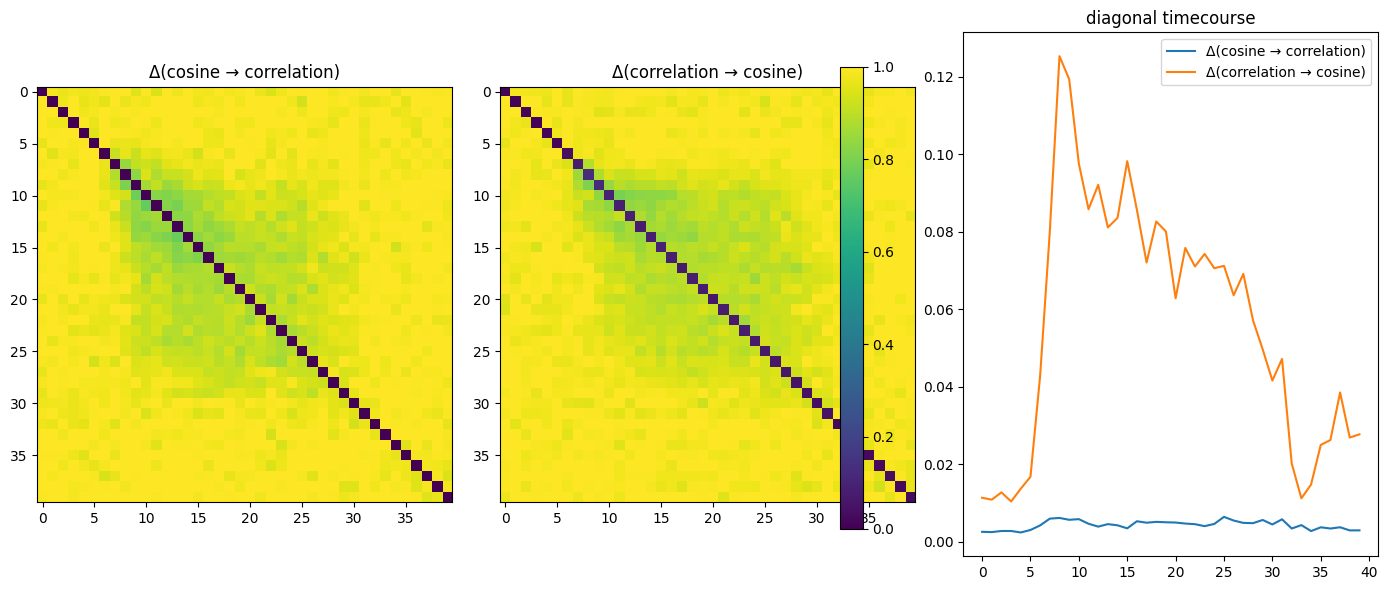

In [106]:
# check possible interferences between static_dynII and dynII...

fig, ax = plt.subplots(1, 3, figsize=(14, 6))

# Plot both images with the same limits
im = ax[0].imshow(dynII_A2B, vmin=0, vmax=1)
ax[0].set_title(f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
ax[1].imshow(dynII_B2A, vmin=0, vmax=1)
ax[1].set_title(f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
fig.colorbar(im, ax=ax[:2], fraction=0.046, pad=0.04)  # fraction/pad adjust size/spacing
ax[2].plot(np.diag(dynII_A2B), label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
ax[2].plot(np.diag(dynII_B2A), label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
ax[2].set_title("diagonal timecourse")
ax[2].legend()
# Add one colorbar for both axes
plt.tight_layout()
plt.show()


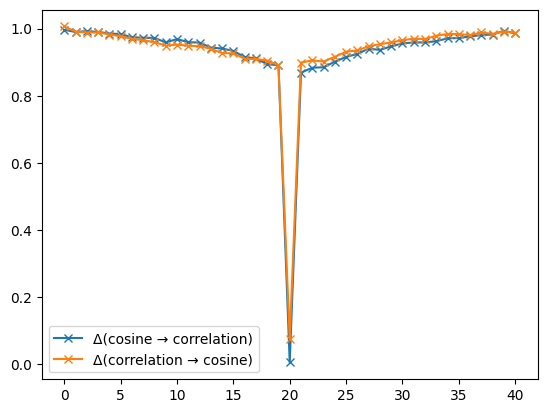

In [100]:
from general_utils.utils import get_lagplot, get_lagplot_subset
plt.plot(get_lagplot_subset(dynII_A2B, np.arange(10,30)), marker="x", label=f"{chr(916)}({cfg.RDM_metric_A} {chr(8594)} {cfg.RDM_metric_B})")
plt.plot(get_lagplot_subset(dynII_B2A, np.arange(10,30)), marker='x', label=f"{chr(916)}({cfg.RDM_metric_B} {chr(8594)} {cfg.RDM_metric_A})")
plt.legend()

### model-based static dynamic II

In [119]:
dyn_ii_obj.set_RDM_metrics(cfg.RDM_metric_A, "model")
dyn_ii_obj.compute_RDM(feats, "model")

array([0.08431035, 0.03992951, 0.03756309, ..., 0.11653143, 0.00868082,
       0.09164238])

In [120]:
dyn_ii_obj.compute_distance_ranks("model")
dyn_ii_obj.compute_distance_ranks_timeseries("signal")

In [83]:
stat_dyn_A2B, stat_dyn_B2A = dyn_ii_obj.compute_both_static_dynII()

In [123]:
dyn_ii_obj.model_kmins_idx.shape

(1, 1000)

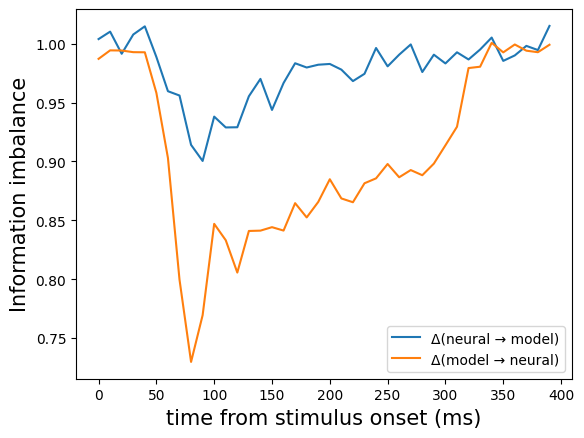

In [113]:
plt.plot(np.arange(len(stat_dyn_A2B))*1000//cfg.new_fs, stat_dyn_A2B.get_array(), label=f"{chr(916)}(neural {chr(8594)} model)")
plt.plot(np.arange(len(stat_dyn_A2B))*1000//cfg.new_fs, stat_dyn_B2A.get_array(), label=f"{chr(916)}(model {chr(8594)} neural)")
plt.ylabel("Information imbalance", fontsize=15)
plt.xlabel("time from stimulus onset (ms)", fontsize=15)
plt.legend()